In [ ]:
!pip install opencv-python numpy pandas scikit-learn tensorflow

In [ ]:
!pip uninstall -y mediapipe mediapipe-model-maker

In [ ]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
import os
import mediapipe as mp
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout

In [ ]:
TRAIN_VIDEO_DATASET_PATH = "/content/drive/MyDrive/DATN/SignLanguageProject/data/raw/actions/trains"
TEST_VIDEO_DATASET_PATH = "/content/drive/MyDrive/DATN/SignLanguageProject/data/raw/actions/tests"

TRAIN_NPY_PATH = "/content/drive/MyDrive/DATN/SignLanguageProject/data/processed/actions/trains/"
TEST_NPY_PATH = "/content/drive/MyDrive/DATN/SignLanguageProject/data/processed/actions/tests/"

# Đường dẫn để lưu file model tốt nhất
MODEL_SAVE_PATH = "/content/drive/MyDrive/DATN/SignLanguageProject/models/model_actions.keras"

SEQUENCE_LENGTH = 30 # Số frame mỗi video
EPOCHS = 100
BATCH_SIZE = 32

In [ ]:
# --- CELL 3: HELPER FUNCTIONS ---
mp_holistic = mp.solutions.holistic

def extract_keypoints(results):
    """
    Trích xuất tọa độ tay trái và phải (21x3 + 21x3 = 126 điểm)
    """
    # TAY TRÁI
    if results.left_hand_landmarks:
        l_res = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark])
        wrist = l_res[0, :]
        l_res = l_res - wrist # Chuẩn hóa theo cổ tay
        lh = l_res.flatten()
    else:
        lh = np.zeros(21*3)

    # TAY PHẢI
    if results.right_hand_landmarks:
        r_res = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark])
        wrist = r_res[0, :]
        r_res = r_res - wrist # Chuẩn hóa theo cổ tay
        rh = r_res.flatten()
    else:
        rh = np.zeros(21*3)

    return np.concatenate([lh, rh])

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

def process_video_sequence(video_path, sequence_length=30):
    """
    Hàm xử lý Uniform Sampling:
    - Nếu video dài > 30 frame: Cắt bớt (nhảy cóc).
    - Nếu video ngắn < 30 frame: Lặp lại frame.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    # Tạo danh sách các chỉ số frame cần lấy
    frame_indices = np.linspace(0, total_frames - 1, sequence_length, dtype=int)

    frames_data = []

    with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        for i in range(total_frames):
            ret, frame = cap.read()
            if not ret: break

            # Chỉ xử lý nếu frame này nằm trong danh sách cần lấy
            if i in frame_indices:
                # Đếm số lần frame này xuất hiện trong danh sách (để lặp lại nếu cần)
                count = np.count_nonzero(frame_indices == i)

                image, results = mediapipe_detection(frame, holistic)
                keypoints = extract_keypoints(results)

                for _ in range(count):
                    frames_data.append(keypoints)

    cap.release()

    # Trả về mảng numpy (30, 126)
    return np.array(frames_data)

In [ ]:
from tensorflow.keras.utils import to_categorical
import os
import numpy as np

SAVE_PATH_X_TRAIN_VAL = os.path.join(TRAIN_NPY_PATH, "X_actions_train_val.npy")
SAVE_PATH_Y_TRAIN_VAL = os.path.join(TRAIN_NPY_PATH, "y_actions_train_val.npy")
SAVE_PATH_X_TEST = os.path.join(TEST_NPY_PATH, "X_actions_test.npy")
SAVE_PATH_Y_TEST = os.path.join(TEST_NPY_PATH, "y_actions_test.npy")
SAVE_PATH_ACTIONS = os.path.join(TRAIN_NPY_PATH, "actions_list.npy") # Actions list is the same for both

FORCE_PROCESS = False # Đổi thành True nếu bạn muốn quét lại dữ liệu mới

X_train_val, y_train_val = None, None
X_test, y_test = None, None

# --- Xử lý tập TRAIN/VAL ---
if os.path.exists(SAVE_PATH_X_TRAIN_VAL) and not FORCE_PROCESS:
    print("✅ Đã tìm thấy dữ liệu TRAIN/VAL cũ! Đang load...")
    X_train_val = np.load(SAVE_PATH_X_TRAIN_VAL)
    y_train_val = np.load(SAVE_PATH_Y_TRAIN_VAL)
else:
    print("⚠️ Bắt đầu xử lý video TRAIN/VAL...")
    sequences_train_val, labels_train_val = [], []

    # Lấy danh sách tên hành động từ tên thư mục TRAIN
    actions = np.array([f for f in os.listdir(TRAIN_VIDEO_DATASET_PATH) if os.path.isdir(os.path.join(TRAIN_VIDEO_DATASET_PATH, f))])
    actions.sort()
    label_map = {label:num for num, label in enumerate(actions)}
    print(f"Danh sách hành động (tập TRAIN/VAL): {actions}")

    for action in actions:
        action_path = os.path.join(TRAIN_VIDEO_DATASET_PATH, action)
        video_files = [f for f in os.listdir(action_path) if f.endswith(('.avi', '.mp4'))]
        print(f"--> Đang xử lý tập TRAIN/VAL: {action} ({len(video_files)} video)")

        for video_file in video_files:
            video_path = os.path.join(action_path, video_file)
            window = process_video_sequence(video_path, SEQUENCE_LENGTH)

            if window is not None and len(window) == SEQUENCE_LENGTH:
                sequences_train_val.append(window)
                labels_train_val.append(label_map[action])

    X_train_val = np.array(sequences_train_val)
    y_train_val = to_categorical(labels_train_val).astype(int)

    # Tạo thư mục và lưu file
    os.makedirs(TRAIN_NPY_PATH, exist_ok=True)
    np.save(SAVE_PATH_X_TRAIN_VAL, X_train_val)
    np.save(SAVE_PATH_Y_TRAIN_VAL, y_train_val)
    np.save(SAVE_PATH_ACTIONS, actions)
    print(f"✅ Đã lưu xong dữ liệu TRAIN/VAL! X_train_val: {X_train_val.shape}, y_train_val: {y_train_val.shape}")

# --- Xử lý tập TEST ---
if os.path.exists(SAVE_PATH_X_TEST) and not FORCE_PROCESS:
    print("✅ Đã tìm thấy dữ liệu TEST cũ! Đang load...")
    X_test = np.load(SAVE_PATH_X_TEST)
    y_test = np.load(SAVE_PATH_Y_TEST)
else:
    print("⚠️ Bắt đầu xử lý video TEST...")
    sequences_test, labels_test = [], []

    # Lấy danh sách tên hành động từ tên thư mục TEST (giả định giống TRAIN)
    test_actions = np.array([f for f in os.listdir(TEST_VIDEO_DATASET_PATH) if os.path.isdir(os.path.join(TEST_VIDEO_DATASET_PATH, f))])
    test_actions.sort()
    # Kiểm tra xem danh sách hành động trong TEST có khớp với TRAIN không
    if not np.array_equal(actions, test_actions):
        print("Cảnh báo: Danh sách hành động trong thư mục TEST khác với TRAIN. Vui lòng kiểm tra lại dữ liệu.")
        # Bạn có thể chọn dừng lại hoặc xử lý lỗi khác tùy theo yêu cầu

    for action in actions: # Dùng label_map từ tập TRAIN
        action_path = os.path.join(TEST_VIDEO_DATASET_PATH, action)
        video_files = [f for f in os.listdir(action_path) if f.endswith(('.avi', '.mp4'))]
        print(f"--> Đang xử lý tập TEST: {action} ({len(video_files)} video)")

        for video_file in video_files:
            video_path = os.path.join(action_path, video_file)
            window = process_video_sequence(video_path, SEQUENCE_LENGTH)

            if window is not None and len(window) == SEQUENCE_LENGTH:
                sequences_test.append(window)
                labels_test.append(label_map[action])

    X_test = np.array(sequences_test)
    y_test = to_categorical(labels_test).astype(int)

    # Tạo thư mục và lưu file
    os.makedirs(TEST_NPY_PATH, exist_ok=True)
    np.save(SAVE_PATH_X_TEST, X_test)
    np.save(SAVE_PATH_Y_TEST, y_test)
    print(f"✅ Đã lưu xong dữ liệu TEST! X_test: {X_test.shape}, y_test: {y_test.shape}")

⚠️ Bắt đầu xử lý video TRAIN/VAL...
Danh sách hành động (tập TRAIN/VAL): ['A' 'Â' 'Ă' 'B' 'Bạn khỏe không' 'C' 'Cảm ơn' 'Chào'
 'Chúc may mắn' 'D' 'E' 'Ê' 'G' 'H' 'Hẹn gặp lại' 'I' 'K' 'L' 'M'
 'N' 'O' 'Ô' 'Ơ' 'P' 'Q' 'R' 'Rất vui được gặp bạn' 'S' 'T'
 'Tạm biệt' 'Tôi ăn cơm' 'Tôi khỏe' 'U' 'Ư' 'V' 'X' 'Xin lỗi'
 'Y' 'Đ']
--> Đang xử lý tập TRAIN/VAL: A (56 video)


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


--> Đang xử lý tập TRAIN/VAL: Â (56 video)
--> Đang xử lý tập TRAIN/VAL: Ă (54 video)
--> Đang xử lý tập TRAIN/VAL: B (56 video)
--> Đang xử lý tập TRAIN/VAL: Bạn khỏe không (56 video)
--> Đang xử lý tập TRAIN/VAL: C (55 video)
--> Đang xử lý tập TRAIN/VAL: Cảm ơn (56 video)
--> Đang xử lý tập TRAIN/VAL: Chào (56 video)
--> Đang xử lý tập TRAIN/VAL: Chúc may mắn (56 video)
--> Đang xử lý tập TRAIN/VAL: D (56 video)
--> Đang xử lý tập TRAIN/VAL: E (56 video)
--> Đang xử lý tập TRAIN/VAL: Ê (56 video)
--> Đang xử lý tập TRAIN/VAL: G (56 video)
--> Đang xử lý tập TRAIN/VAL: H (56 video)
--> Đang xử lý tập TRAIN/VAL: Hẹn gặp lại (55 video)
--> Đang xử lý tập TRAIN/VAL: I (56 video)
--> Đang xử lý tập TRAIN/VAL: K (56 video)
--> Đang xử lý tập TRAIN/VAL: L (56 video)
--> Đang xử lý tập TRAIN/VAL: M (56 video)
--> Đang xử lý tập TRAIN/VAL: N (56 video)
--> Đang xử lý tập TRAIN/VAL: O (56 video)
--> Đang xử lý tập TRAIN/VAL: Ô (57 video)
--> Đang xử lý tập TRAIN/VAL: Ơ (56 v

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import numpy as np

# Giả sử X_test, y_test đã chiếm 20% tổng dữ liệu và được tách riêng từ trước
# X_train_val hiện tại đang chiếm 80% tổng dữ liệu ban đầu

# 1. Chia X_train_val (80%) thành tập Train (60% tổng) và Val (20% tổng)
# Tỉ lệ Val trong tập train_val sẽ là: 20 / 80 = 0.25 (tức 25%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25, # 25% của 80% = 20% tổng dữ liệu
    random_state=42,
    stratify=np.argmax(y_train_val, axis=1)
)

# 2. Hàm thêm nhiễu (Data Augmentation)
def augment_data(sequences):
    augmented_sequences = []
    for seq in sequences:
        # Thêm nhiễu Gaussian nhẹ (0.02)
        noise = np.random.normal(0, 0.02, seq.shape)
        augmented_sequences.append(seq + noise)
    return np.array(augmented_sequences)

# 3. Chỉ Augment trên tập Train để tránh "data leakage" (rò rỉ dữ liệu)
print(f"Kích thước Train gốc: {X_train.shape}")
X_train_aug = augment_data(X_train)

# 4. Gộp dữ liệu gốc và dữ liệu nhiễu, sau đó trộn đều
X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train])
X_train, y_train = shuffle(X_train, y_train, random_state=42)

print(f"--> Kết quả phân chia cuối cùng (Tính trên tổng dataset):")
print(f"--> Train (Sau augment nhân đôi): {X_train.shape}")
print(f"--> Validation (20%): {X_val.shape}")
print(f"--> Test (20% đã chia trước): {X_test.shape}")

Kích thước Train gốc: (1635, 30, 126)
--> Kết quả phân chia cuối cùng (Tính trên tổng dataset):
--> Train (Sau augment nhân đôi): (3270, 30, 126)
--> Validation (20%): (546, 30, 126)
--> Test (20% đã chia trước): (544, 30, 126)


In [ ]:
# --- CELL 6: BUILD MODEL ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
import numpy as np # Import numpy

# Load actions list
# SAVE_PATH_ACTIONS is defined in cell GcE75SFa-Jfj
SAVE_PATH_ACTIONS = "/content/drive/MyDrive/DATN/SignLanguageProject/data/processed/actions/trains/actions_list.npy"
actions = np.load(SAVE_PATH_ACTIONS)

model = Sequential()

# Layer 1: Bi-LSTM
model.add(Bidirectional(LSTM(64, return_sequences=True, activation='tanh'), input_shape=(SEQUENCE_LENGTH, 126)))
model.add(Dropout(0.2))

# Layer 2: Bi-LSTM
model.add(Bidirectional(LSTM(64, return_sequences=True, activation='tanh')))
model.add(Dropout(0.2))

# Layer 3: Bi-LSTM (Kết thúc chuỗi)
model.add(Bidirectional(LSTM(32, return_sequences=False, activation='tanh')))

# Fully Connected Layers
model.add(Dense(64, activation='relu')) # Dùng relu tốt hơn tanh cho Dense
model.add(Dense(32, activation='relu'))

# Output
model.add(Dense(len(actions), activation='softmax'))

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        97,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 39)             │         1,287 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,351 (958.40 KB)

 Trainable params: 245,351 (958.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- CELL 7: TRAINING ---
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Checkpoint: Chỉ lưu model tốt nhất
checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_categorical_accuracy', verbose=1, save_best_only=True, mode='max')

# EarlyStopping: Dừng nếu không học thêm được gì sau 20 epochs
early_stopping = EarlyStopping(monitor='val_categorical_accuracy', patience=20, restore_best_weights=True)

# ReduceLR: Giảm tốc độ học khi gặp khó
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

print("🚀 Bắt đầu training...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    validation_data=(X_val, y_val) # Sử dụng tập validation mới
)

🚀 Bắt đầu training...
Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.1247 - loss: 3.3092
Epoch 1: val_categorical_accuracy improved from -inf to 0.51832, saving model to /content/drive/MyDrive/DATN/SignLanguageProject/models/model_actions.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - categorical_accuracy: 0.1258 - loss: 3.3040 - val_categorical_accuracy: 0.5183 - val_loss: 1.5468 - learning_rate: 0.0010
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - categorical_accuracy: 0.5728 - loss: 1.2955
Epoch 2: val_categorical_accuracy improved from 0.51832 to 0.64286, saving model to /content/drive/MyDrive/DATN/SignLanguageProject/models/model_actions.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - categorical_accuracy: 0.5734 - loss: 1.2937 - val_categorical_accuracy: 0.6429 - val_loss: 0.9469 - learning_rate: 0.0010
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - categorical_accuracy: 0.7570 - loss: 0.6718
Epoch 3: val_categorical_accur

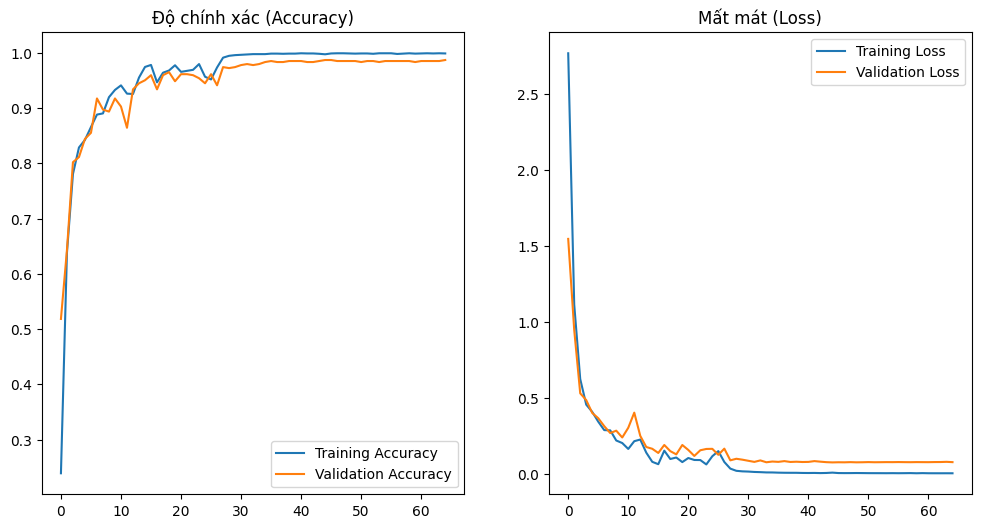

In [ ]:
# --- CELL 8: VISUALIZATION (Đã sửa lỗi import) ---
import matplotlib.pyplot as plt  # <--- Thêm dòng này để sửa lỗi

def plot_history(history):
    # Lấy dữ liệu từ lịch sử huấn luyện
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))

    # Biểu đồ độ chính xác (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Độ chính xác (Accuracy)')

    # Biểu đồ mất mát (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Mất mát (Loss)')

    plt.show()

# Gọi hàm vẽ
if 'history' in globals():
    plot_history(history)
else:
    print("⚠️ Chưa tìm thấy biến 'history'. Bạn đã chạy Cell 7 (Training) xong chưa?")

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score, classification_report

# --- CELL 9: EVALUATION ---

print("Đang tải mô hình tốt nhất đã lưu...")
model = load_model(MODEL_SAVE_PATH)

print("Đang đánh giá mô hình trên tập kiểm tra...")
y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tính toán độ chính xác và mất mát trên tập kiểm tra
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nKết quả trên tập kiểm tra:")
print(f"  Loss: {loss:.4f}")
print(f"  Accuracy: {accuracy:.4f}")

# Báo cáo phân loại chi tiết hơn
print("\nBáo cáo phân loại:")
print(classification_report(y_true, y_pred_classes, target_names=actions))

Đang tải mô hình tốt nhất đã lưu...
Đang đánh giá mô hình trên tập kiểm tra...
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Kết quả trên tập kiểm tra:
  Loss: 0.2100
  Accuracy: 0.9669

Báo cáo phân loại:
                              precision    recall  f1-score   support

                           A       1.00      1.00      1.00        14
                          Â       1.00      1.00      1.00        14
                          Ă       1.00      1.00      1.00        14
                           B       1.00      0.83      0.91        12
           Bạn khỏe không       1.00      1.00      1.00        14
                           C       0.93      1.00      0.97        14
                    Cảm ơn       1.00      1.00      1.00        14
                       Chào       1.00      0.93      0.96        14
             Chúc may mắn       0.93      1.00      0.97        14
                           D       1.00      1.00      1.00        14
                           E

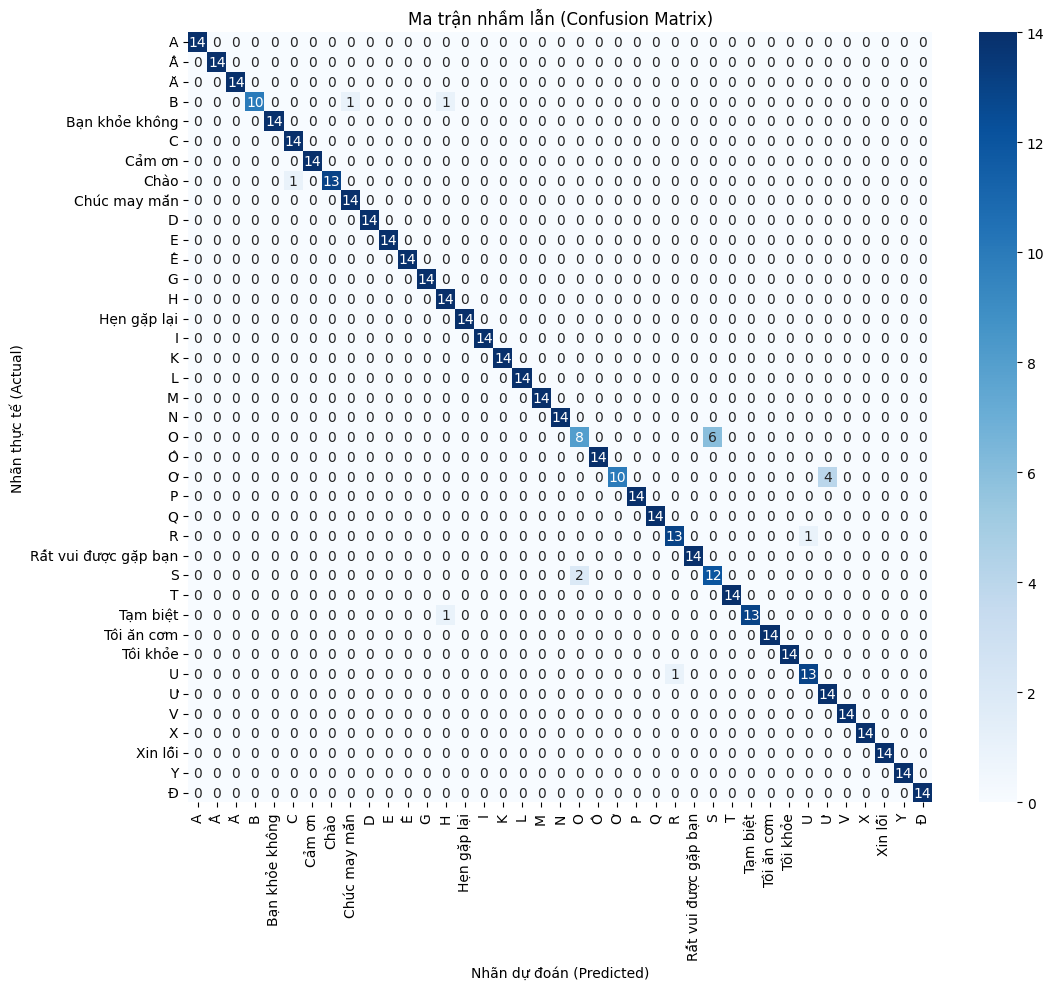

Độ chính xác lớp 'A': 100.00%
Độ chính xác lớp 'Â': 100.00%
Độ chính xác lớp 'Ă': 100.00%
Độ chính xác lớp 'B': 83.33%
Độ chính xác lớp 'Bạn khỏe không': 100.00%
Độ chính xác lớp 'C': 100.00%
Độ chính xác lớp 'Cảm ơn': 100.00%
Độ chính xác lớp 'Chào': 92.86%
Độ chính xác lớp 'Chúc may mắn': 100.00%
Độ chính xác lớp 'D': 100.00%
Độ chính xác lớp 'E': 100.00%
Độ chính xác lớp 'Ê': 100.00%
Độ chính xác lớp 'G': 100.00%
Độ chính xác lớp 'H': 100.00%
Độ chính xác lớp 'Hẹn gặp lại': 100.00%
Độ chính xác lớp 'I': 100.00%
Độ chính xác lớp 'K': 100.00%
Độ chính xác lớp 'L': 100.00%
Độ chính xác lớp 'M': 100.00%
Độ chính xác lớp 'N': 100.00%
Độ chính xác lớp 'O': 57.14%
Độ chính xác lớp 'Ô': 100.00%
Độ chính xác lớp 'Ơ': 71.43%
Độ chính xác lớp 'P': 100.00%
Độ chính xác lớp 'Q': 100.00%
Độ chính xác lớp 'R': 92.86%
Độ chính xác lớp 'Rất vui được gặp bạn': 100.00%
Độ chính xác lớp 'S': 85.71%
Độ chính xác lớp 'T': 100.00%
Độ chính xác lớp 'Tạm biệt': 92.86%
Độ chính x

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt # Thêm dòng này để import thư viện vẽ biểu đồ

# 1. Tính toán ma trận nhầm lẫn
# Biến y_true và y_pred_classes được định nghĩa trong ô trước đó (9865ff4b).
# Nếu bạn vẫn gặp NameError, hãy đảm bảo ô 9865ff4b đã được chạy thành công trước ô này.
cm = confusion_matrix(y_true, y_pred_classes)

# 2. Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actions, yticklabels=actions)

plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Nhãn thực tế (Actual)')
plt.xlabel('Nhãn dự đoán (Predicted)')
plt.show()

# 3. Tính toán độ chính xác cho từng lớp (Class-wise Accuracy)
cm_acc = cm.diagonal() / cm.sum(axis=1)
for action, acc in zip(actions, cm_acc):
    print(f"Độ chính xác lớp '{action}': {acc*100:.2f}%")